# Second-Order Expansion Validation

This notebook checks whether the second-order fields from `compute_second_order` satisfy:
- the modal PDEs for `n=0,2` and pieces `A,B`,
- center/outer boundary conditions,
- shape constraints through `rho20*` and `rho22*`.

Use it by editing `params`, running the validation cell, and inspecting the residual plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from first_order import build_first_order
from second_order import compute_second_order, make_forcings_A_B_func
from verify_numerics import check_second_order_pde_discrete

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


In [2]:
params = {
    "P": 0.015915,
    "Z": 0.159155,
    "gamma": 0.0025,
    "root_index": 0,
    "N_init": 600,
    "eps_factor": 1e-6,
    "mesh_power": 3.0,
}
params


{'P': 0.015915,
 'Z': 0.159155,
 'gamma': 0.0025,
 'root_index': 0,
 'N_init': 600,
 'eps_factor': 1e-06,
 'mesh_power': 3.0}

In [3]:
def _derivs(y, x):
    yp = np.gradient(y, x, edge_order=2)
    ypp = np.gradient(yp, x, edge_order=2)
    return yp, ypp


def _Ln(n, f, r):
    fp, fpp = _derivs(f, r)
    return fpp + fp / r - (n ** 2) * f / (r ** 2), fp


def _piece_mode_arrays(piece, mode):
    if mode == 0:
        return piece.r, piece.s0, piece.m0
    if mode == 2:
        return piece.r, piece.s2, piece.m2
    raise ValueError("mode must be 0 or 2")


def run_validation(
    P,
    Z,
    gamma,
    root_index=0,
    N_init=600,
    eps_factor=1e-6,
    mesh_power=3.0,
    modes=(0, 2),
    plot=True,
):
    F = build_first_order(P=P, Z=Z, gamma=gamma, root_index=root_index)
    SO = compute_second_order(
        F,
        modes=modes,
        eps_factor=eps_factor,
        N_init=N_init,
        mesh_power=mesh_power,
    )

    report = check_second_order_pde_discrete(F, SO, modes=modes)

    def _integral_loss(piece_name, n_theta=4096):
        piece = SO.A if piece_name == "A" else SO.B
        rho20 = SO.rho20A if piece_name == "A" else SO.rho20B
        rho22 = SO.rho22A if piece_name == "A" else SO.rho22B
        r = piece.r
        m20 = piece.m0
        m22 = piece.m2

        theta = np.linspace(0.0, 2.0 * np.pi, int(n_theta), endpoint=False)
        cos2 = np.cos(2.0 * theta)

        radial0 = np.trapezoid(2.0 * r * m20, r)
        radial2 = np.trapezoid(2.0 * r * m22, r)
        integrand = 2.0 * F.m0 * F.R0 * (rho20 + rho22 * cos2) + (radial0 + radial2 * cos2)
        return float((2.0 * np.pi / theta.size) * np.sum(integrand))

    def _integral_loss_alt(piece_name):
        piece = SO.A if piece_name == "A" else SO.B
        rho20 = SO.rho20A if piece_name == "A" else SO.rho20B
        r = piece.r
        m20 = piece.m0
        radial0 = np.trapezoid(2.0 * r * m20, r)
        return float(4.0 * np.pi * F.m0 * F.R0 * rho20 + 2.0 * np.pi * radial0)

    integral_losses = {name: _integral_loss(name) for name in ("A", "B")}
    integral_losses_alt = {name: _integral_loss_alt(name) for name in ("A", "B")}
    report["integral_loss"] = integral_losses
    report["integral_loss_alt"] = integral_losses_alt

    print(f"R0={F.R0:.6g}, m0={F.m0:.6g}, Khat0={F.Khat0:.6g}, alpha={F.alpha:.6g}")
    print(f"total validation loss = {report['loss']:.3e}")
    print()

    header = (
        f"{'piece':<6}{'mode':<6}{'pde':>12}{'bc_center':>12}"
        f"{'bc_outer':>12}{'bc_shape':>12}{'loss':>12}"
    )
    print(header)
    print('-' * len(header))

    for piece_name in ("A", "B"):
        for mode in modes:
            d = report["details"][piece_name][mode]
            bc_center = d["bc_center_s"] + d["bc_center_m"]
            bc_outer = d["bc_outer_s"] + d["bc_outer_m"]
            print(
                f"{piece_name:<6}{mode:<6}{d['pde_L2_total']:>12.3e}"
                f"{bc_center:>12.3e}{bc_outer:>12.3e}"
                f"{d['bc_shape']:>12.3e}{d['loss']:>12.3e}"
            )

    print()
    print("integral loss: int_0^{2pi}[2 m0 R0 (R20 + R22 cos(2 theta)) + int_0^{R0} 2 r (m20 + cos(2 theta) m22) dr] dtheta")
    print("alt integral loss: 4pi m0 R0 rho20 + 2pi int_0^{R0} 2r m20 dr")
    for piece_name in ("A", "B"):
        val = integral_losses[piece_name]
        val_alt = integral_losses_alt[piece_name]
        print(f"{piece_name:<6} value={val: .3e}  alt={val_alt: .3e}  abs={abs(val):.3e}  abs_alt={abs(val_alt):.3e}")

    if plot:
        Q = make_forcings_A_B_func(F)
        q_lookup = {
            ("A", 0): Q["qA0"],
            ("A", 2): Q["qA2"],
            ("B", 0): Q["qB0"],
            ("B", 2): Q["qB2"],
        }

        fig, axes = plt.subplots(len(modes), 4, figsize=(16, 4 * len(modes)), squeeze=False)

        for i, mode in enumerate(modes):
            for j, piece_name in enumerate(("A", "B")):
                piece = SO.A if piece_name == "A" else SO.B
                r, s, m = _piece_mode_arrays(piece, mode)

                Ln_s, _ = _Ln(mode, s, r)
                Ln_m, _ = _Ln(mode, m, r)
                q = q_lookup[(piece_name, mode)](r)

                res_sigma = F.Z * Ln_s - (s - F.P * m)
                res_m = Ln_m - (F.Khat0 * F.m0) * Ln_s - q

                ax_profile = axes[i, 2 * j]
                ax_res = axes[i, 2 * j + 1]

                ax_profile.plot(r, 1000*s, label=f"1000 times s{mode}")
                ax_profile.plot(r, m, label=f"m{mode}")
                ax_profile.set_title(f"{piece_name}, mode {mode}: profiles")
                ax_profile.set_xlabel("r")
                ax_profile.legend()

                ax_res.semilogy(r, np.abs(res_sigma) + 1e-30, label="|sigma PDE residual|")
                ax_res.semilogy(r, np.abs(res_m) + 1e-30, label="|m PDE residual|")
                ax_res.set_title(f"{piece_name}, mode {mode}: residuals")
                ax_res.set_xlabel("r")
                ax_res.legend()

        plt.tight_layout()
        plt.show()

    return F, SO, report


R0=0.558311, m0=1.02117, Khat0=116.205, alpha=1.31919
total validation loss = 2.659e-03

piece mode           pde   bc_center    bc_outer    bc_shape        loss
------------------------------------------------------------------------
A     0        1.228e-03   8.922e-07   4.839e-07   0.000e+00   1.229e-03
A     2        7.733e-05   2.819e-13   8.695e-06   1.084e-19   8.603e-05
B     0        1.254e-03   9.042e-07   4.941e-07   0.000e+00   1.255e-03
B     2        7.897e-05   2.879e-13   8.879e-06   5.421e-20   8.785e-05

integral loss: int_0^{2pi}[2 m0 R0 (R20 + R22 cos(2 theta)) + int_0^{R0} 2 r (m20 + cos(2 theta) m22) dr] dtheta
A      value= 5.067e-02  abs=5.067e-02
B      value=-4.946e-02  abs=4.946e-02


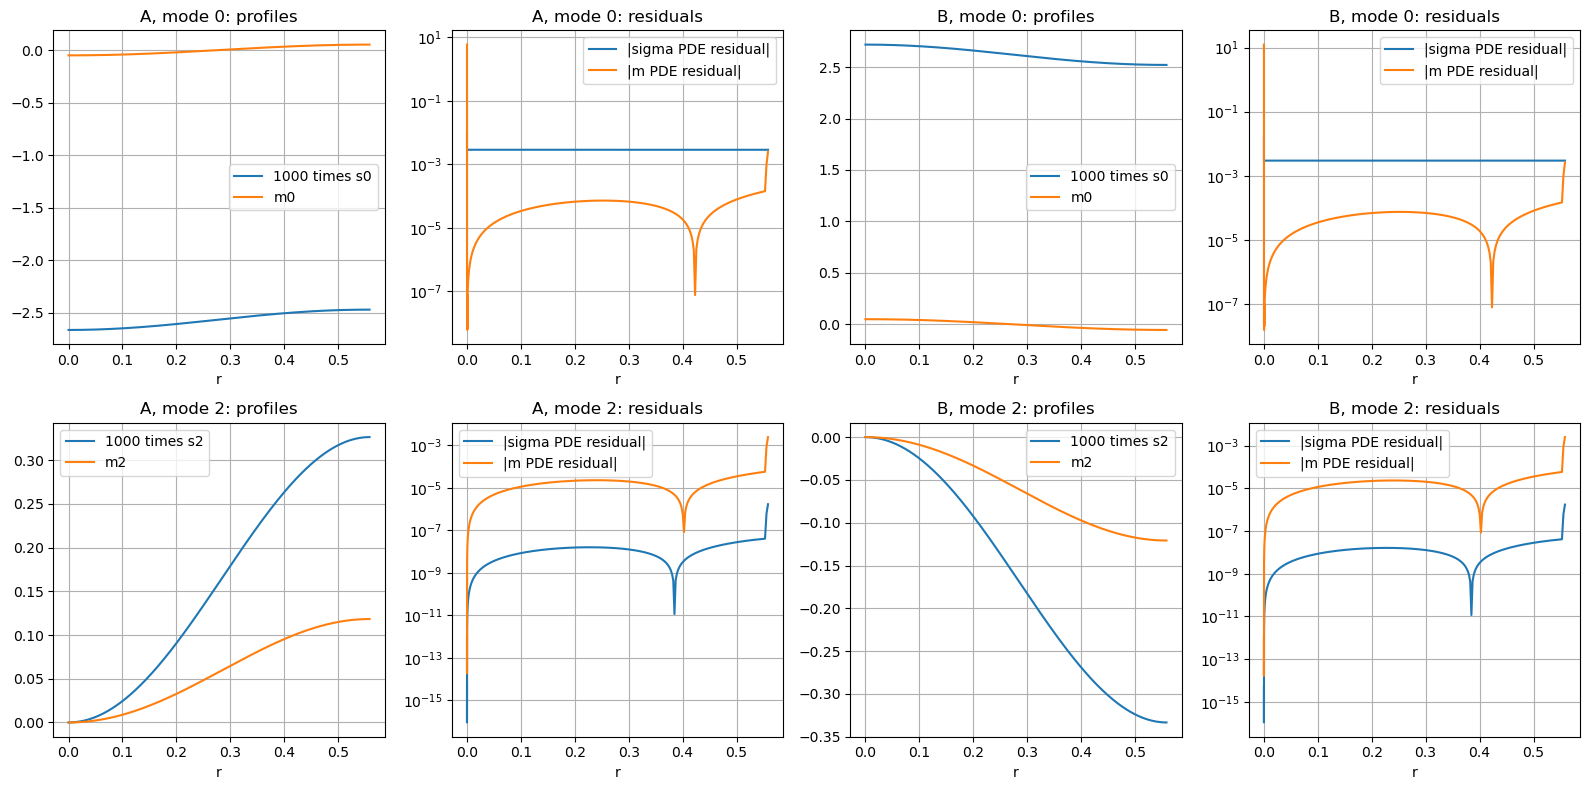

In [4]:
F, SO, report = run_validation(**params)


In [16]:
# Optional interactive controls (requires ipywidgets).
try:
    import ipywidgets as widgets
    from ipywidgets import interact

    interact(
        lambda P, Z, gamma, N_init, mesh_power: run_validation(
            P=P,
            Z=Z,
            gamma=gamma,
            root_index=params["root_index"],
            N_init=int(N_init),
            eps_factor=params["eps_factor"],
            mesh_power=mesh_power,
            plot=True,
        ),
        P=widgets.FloatText(value=params["P"], description="P"),
        Z=widgets.FloatText(value=params["Z"], description="Z"),
        gamma=widgets.FloatText(value=params["gamma"], description="gamma"),
        N_init=widgets.IntSlider(value=params["N_init"], min=200, max=2000, step=100, description="N_init"),
        mesh_power=widgets.FloatSlider(value=params["mesh_power"], min=1.0, max=5.0, step=0.25, description="mesh"),
    )
except Exception as exc:
    print("ipywidgets is unavailable in this environment.")
    print(f"Reason: {exc}")
    print("Edit `params` and rerun `run_validation(**params)` instead.")


interactive(children=(FloatText(value=0.015915, description='P'), FloatText(value=0.159155, description='Z'), …